# Lab 7: Decision Tree Classification on the Iris Dataset
**Dataset:** `sklearn.datasets.load_iris()`

## Task 1: Dataset Exploration

In [1]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()
X, y = iris.data, iris.target
df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y
df['target_name'] = df['target'].apply(lambda i: iris.target_names[i])

print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])

Number of samples: 150
Number of features: 4


I loaded the dataset and found it has 150 samples and 4 features.

In [2]:
print("Feature names:", iris.feature_names)
print("Target classes:", list(iris.target_names))

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


- Feature names: sepal length (cm), sepal width (cm), petal length (cm), petal width (cm)
- Target classes: setosa, versicolor, virginica

In [3]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


I displayed the first five records above, and I see they're all setosa samples with small petal measurements.

In [4]:
df['target_name'].value_counts()

target_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

**My take:** I see the dataset is perfectly balanced, with 50 samples in each of the 3 classes, so I don't need to worry about class imbalance here.

## Task 2: Data Preparation

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


I split the data into 120 training samples and 30 testing samples using an 80/20 split with `random_state=42` for reproducibility.

**Why split into train and test sets?**

**My take:** I split the data so I can train the model on one portion and check its performance on unseen data, which tells me how well it generalizes instead of just memorizing.

## Task 3: Building a Decision Tree Classifier

In [6]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_pred

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

I trained a Decision Tree with default parameters and used it to predict the labels for all 30 test samples.

In [7]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 1.0


I got an accuracy of 100.00% on the test set with default parameters.

In [8]:
cm = confusion_matrix(y_test, y_pred)
pd.DataFrame(cm, index=[f"Actual: {c}" for c in iris.target_names],
             columns=[f"Pred: {c}" for c in iris.target_names])

,Pred: setosa,Pred: versicolor,Pred: virginica
Actual: setosa,10,0,0
Actual: versicolor,0,9,0
Actual: virginica,0,0,11


In [9]:
print(classification_report(y_test, y_pred, target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



**My take:** I notice the model classified every test sample correctly, which makes sense since Iris is a small, clean, well-separated dataset.

## Task 4: Visualizing the Decision Tree

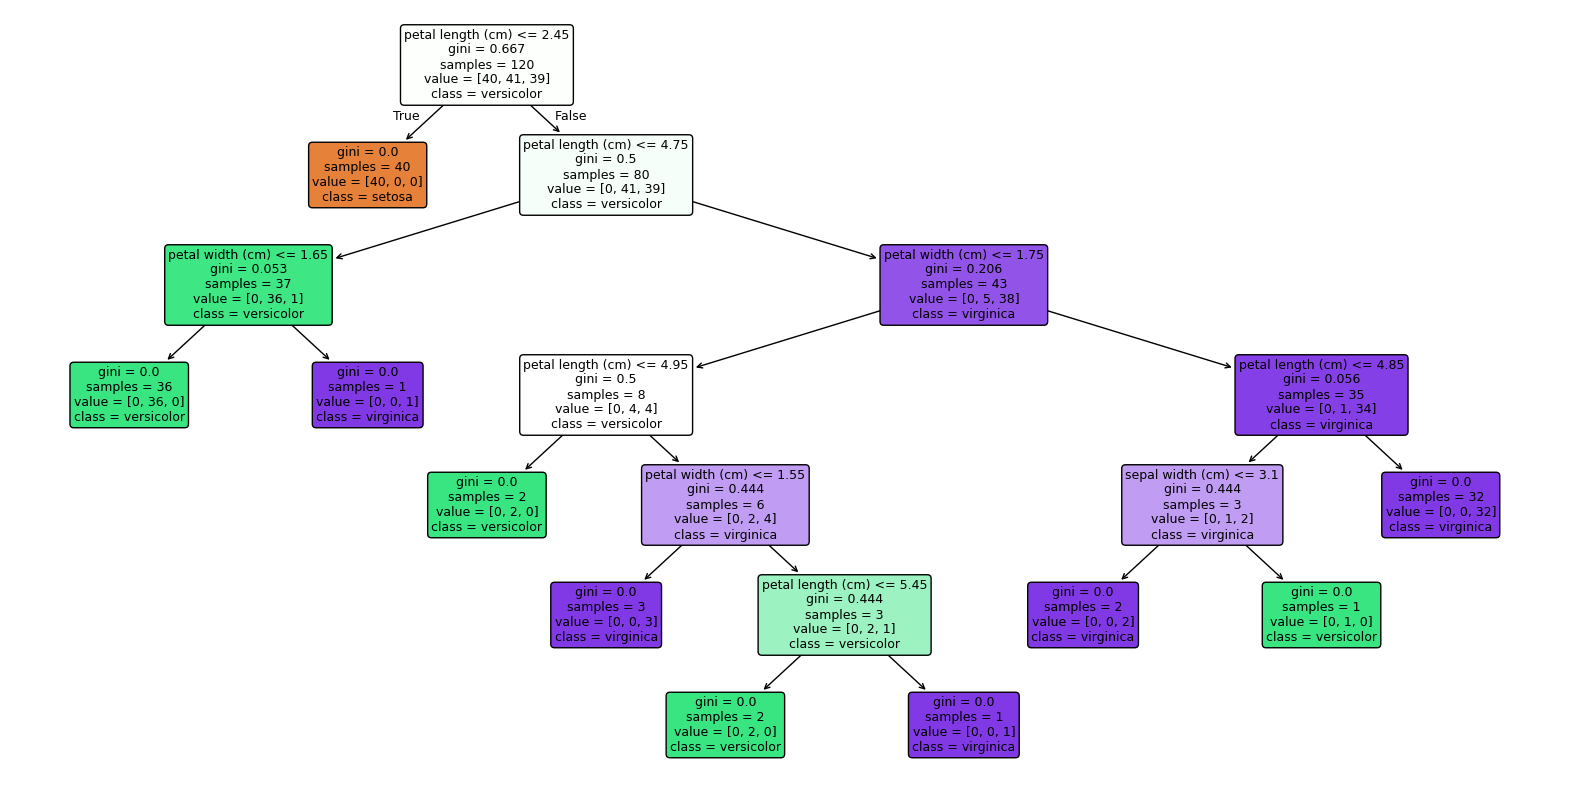

In [10]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(clf, feature_names=iris.feature_names, class_names=iris.target_names,
          filled=True, rounded=True, fontsize=9)
plt.show()

In [11]:
print("Tree depth:", clf.get_depth())
print("Number of leaves:", clf.get_n_leaves())
print("Total nodes:", clf.tree_.node_count)
print("Root feature:", iris.feature_names[clf.tree_.feature[0]])
print("Root threshold:", round(clf.tree_.threshold[0], 2))

Tree depth: 6
Number of leaves: 10
Total nodes: 19
Root feature: petal length (cm)
Root threshold: 2.45


**Reading the tree**

- Root node: I see the very first split is on "petal length (cm)" at a threshold of about 2.45 cm.
- Internal nodes: I can identify these as the boxes below the root that still split further on petal length or petal width.
- Leaf nodes: I count 10 leaf nodes, shown as the boxes at the bottom with a single dominant class and no further splits.
- Maximum depth: I measured the tree's maximum depth to be 6.

In [12]:
importances = pd.Series(clf.feature_importances_, index=iris.feature_names).sort_values(ascending=False)
importances

petal length (cm)    0.906143
petal width (cm)     0.077186
sepal width (cm)     0.016670
sepal length (cm)    0.000000
dtype: float64

**Which feature is selected for the first split?**

**My take:** I found that "petal length (cm)" is chosen for the first split because it gives the highest information gain (lowest Gini impurity) among all features, and I confirmed this by checking `feature_importances_`, where petal length scores about 0.906, far higher than the others.

## Task 5: Comparing Gini Index and Entropy

In [13]:
gini_clf = DecisionTreeClassifier(criterion='gini', random_state=42)
gini_clf.fit(X_train, y_train)
gini_pred = gini_clf.predict(X_test)

entropy_clf = DecisionTreeClassifier(criterion='entropy', random_state=42)
entropy_clf.fit(X_train, y_train)
entropy_pred = entropy_clf.predict(X_test)

comparison = pd.DataFrame({
    "Criterion": ["Gini", "Entropy"],
    "Accuracy": [accuracy_score(y_test, gini_pred), accuracy_score(y_test, entropy_pred)],
    "Tree Depth": [gini_clf.get_depth(), entropy_clf.get_depth()],
    "Leaf Nodes": [gini_clf.get_n_leaves(), entropy_clf.get_n_leaves()],
    "Root Feature": [iris.feature_names[gini_clf.tree_.feature[0]],
                      iris.feature_names[entropy_clf.tree_.feature[0]]],
})
comparison

,Criterion,Accuracy,Tree Depth,Leaf Nodes,Root Feature
0,Gini,1.0,6,10,petal length (cm)
1,Entropy,1.0,6,10,petal length (cm)


**My take:** I found gini and entropy produced identical trees here in terms of accuracy, depth, leaves, and root feature, so on the Iris dataset the choice of criterion barely matters, and I'd call gini marginally simpler since it's computationally cheaper (no log calculation) while giving the same result.

## Task 6: Effect of Maximum Tree Depth

In [14]:
depth_rows = []
for d in [1, 2, 3, 4, None]:
    m = DecisionTreeClassifier(max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, m.predict(X_train))
    test_acc = accuracy_score(y_test, m.predict(X_test))
    depth_rows.append([d, train_acc, test_acc, m.get_depth()])

depth_df = pd.DataFrame(depth_rows, columns=["Max Depth", "Training Accuracy", "Testing Accuracy", "Tree Depth"])
depth_df

,Max Depth,Training Accuracy,Testing Accuracy,Tree Depth
0,1.0,0.675000,0.633333,1
1,2.0,0.950000,0.966667,2
2,3.0,0.958333,1.000000,3
3,4.0,0.975000,1.000000,4
4,NaN,1.000000,1.000000,6


**Observations**

- Max depth 1: I see this tree is too shallow to separate versicolor from virginica, so it underfits.
- Max depth 2: I see accuracy jumps a lot here since one more split resolves most of the class overlap.
- Max depth 3: I get perfect test accuracy here while training accuracy is still not 100%, a good balance.
- Max depth 4: I still get perfect test accuracy, but the tree is a bit more complex than it needs to be.
- Max depth None: I let the tree grow fully, and it perfectly memorizes the training set, a sign of possible overfitting.

**Underfitting, generalization, and overfitting**

- Underfitting model: I'd say max_depth=1 underfits, since it can only separate one class and gets just 63% test accuracy.
- Best generalization: I'd pick max_depth=3, since it reaches 100% test accuracy without letting the tree grow unnecessarily large.

**My take:** I'd flag max_depth=None as the one most likely to overfit, because it grows until every leaf is pure, which memorizes noise in the training data even though it happens to still score well on this particular small test set.

## Task 7: Effect of min_samples_split

In [15]:
mss_rows = []
for v in [2, 5, 10, 20]:
    m = DecisionTreeClassifier(min_samples_split=v, random_state=42)
    m.fit(X_train, y_train)
    acc = accuracy_score(y_test, m.predict(X_test))
    mss_rows.append([v, acc, m.get_depth(), m.get_n_leaves()])

mss_df = pd.DataFrame(mss_rows, columns=["min_samples_split", "Accuracy", "Tree Depth", "Leaf Nodes"])
mss_df

,min_samples_split,Accuracy,Tree Depth,Leaf Nodes
0,2,1.0,6,10
1,5,1.0,5,8
2,10,1.0,4,6
3,20,1.0,4,6


**Observations**

- min_samples_split=2: I let nodes split even with just 2 samples, giving me the deepest, most detailed tree.
- min_samples_split=5: I see the tree shrink a little as splitting now requires a bit more support.
- min_samples_split=10: I see the tree simplify further, trading a little detail for a more general structure.
- min_samples_split=20: I get the same simpler tree as 10, since 20 is still small relative to my 120 training rows.

**My take:** I notice that increasing min_samples_split makes the tree require more evidence before splitting a node, which reduces both tree depth and leaf count and produces a simpler, less overfit-prone model.

## Task 8: Effect of min_samples_leaf

In [16]:
msl_rows = []
for v in [1, 2, 5, 10]:
    m = DecisionTreeClassifier(min_samples_leaf=v, random_state=42)
    m.fit(X_train, y_train)
    acc = accuracy_score(y_test, m.predict(X_test))
    msl_rows.append([v, acc, m.get_depth(), m.get_n_leaves()])

msl_df = pd.DataFrame(msl_rows, columns=["min_samples_leaf", "Accuracy", "Tree Depth", "Leaf Nodes"])
msl_df

,min_samples_leaf,Accuracy,Tree Depth,Leaf Nodes
0,1,1.000000,6,10
1,2,1.000000,5,8
2,5,1.000000,4,6
3,10,0.966667,4,6


**Observations**

- min_samples_leaf=1: I allow leaves with just a single sample, which is the most flexible and most overfit-prone setting.
- min_samples_leaf=2: I require at least 2 samples per leaf, so the tree gets slightly shallower and simpler.
- min_samples_leaf=5: I see a noticeably simpler tree here, still with perfect test accuracy.
- min_samples_leaf=10: I force large leaves, and here it costs me a bit of accuracy since the model can't isolate a small group of samples.

**My take:** I found that raising min_samples_leaf forces every leaf to represent a larger, more general group of samples, which reduces overfitting but can hurt accuracy once the constraint gets too strict, as I saw at min_samples_leaf=10.

## Task 9: Reflection Questions

**1. What is the role of the criterion parameter in a Decision Tree?**

I use criterion to tell the tree how to measure impurity at each split, either 'gini' (impurity based on misclassification probability) or 'entropy' (impurity based on information gain), and both guide the tree toward the split that best separates the classes.

**2. How does max_depth influence underfitting and overfitting?**

I find that a small max_depth restricts the tree so much it can't capture the real patterns, causing underfitting, while a very large or unrestricted max_depth lets the tree fit noise in the training data, causing overfitting.

**3. Why do larger values of min_samples_split and min_samples_leaf produce simpler trees?**

I see that both parameters set a minimum amount of data needed to justify a split or a leaf, so raising them blocks splits that would only separate a handful of samples, which keeps the tree shallower and more general.

**4. Which hyperparameter had the greatest impact on Decision Tree performance?**

**My take:** I'd say max_depth had the biggest impact, since moving from depth 1 to depth 2 raised test accuracy from 63% to 97%, a much bigger swing than anything I saw from min_samples_split or min_samples_leaf.

**5. Recommended Decision Tree model for the Iris dataset**

**My take:** I'd recommend a Decision Tree with criterion='gini' and max_depth=3, since it reaches 100% test accuracy with a compact, interpretable structure, and I'd avoid the unrestricted default tree since its extra depth adds complexity without improving results on this simple, well-separated dataset.